# Modern RNA-Seq Normalization & Quality Control (Python Edition)

This notebook demonstrates modern normalization and quality control techniques for bulk RNA-Sequencing data using native Python libraries.

Because standard R packages like `edgeR` and `limma` do not have native Python ports, this pipeline focuses on **Counts Per Million (CPM)**, **Transcripts Per Million (TPM)**, and the **Median of Ratios** method via the `PyDESeq2` library.

### Prerequisites
Run the following cell to install the required packages if you do not have them:

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn pydeseq2

# 1. Loading Packages and read `airway` Data
We will use the `airway` dataset, a standard bulk RNA-Seq experiment available through Bioconductor. It contains read counts for genes across 8 samples (airway smooth muscle cells treated with dexamethasone vs. untreated).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from pydeseq2.dds import DeseqDataSet

# Load the three files exported from R
raw_counts = pd.read_csv("airway_counts.csv", index_col=0)
gene_info = pd.read_csv("gene_lengths.csv", index_col=0)
metadata = pd.read_csv("airway_metadata.csv", index_col=0)

# Filter metadata to keep only the 'dex' column (treatment labels)
# 'dex' contains 'trt' and 'untrt' [cite: 22, 294]
metadata = metadata[['dex']]

print("Data Loaded Successfully!")
display(raw_counts.head())

Data Loaded Successfully!


,SRR1039508,SRR1039509,SRR1039512,SRR1039513,SRR1039516,SRR1039517,SRR1039520,SRR1039521
ENSG00000000003,679,448,873,408,1138,1047,770,572
ENSG00000000419,467,515,621,365,587,799,417,508
ENSG00000000457,260,211,263,164,245,331,233,229
ENSG00000000460,60,55,40,35,78,63,76,60
ENSG00000000971,3251,3679,6177,4252,6721,11027,5176,7995


# Visualizing Raw Data
## MA Plot of Raw Data


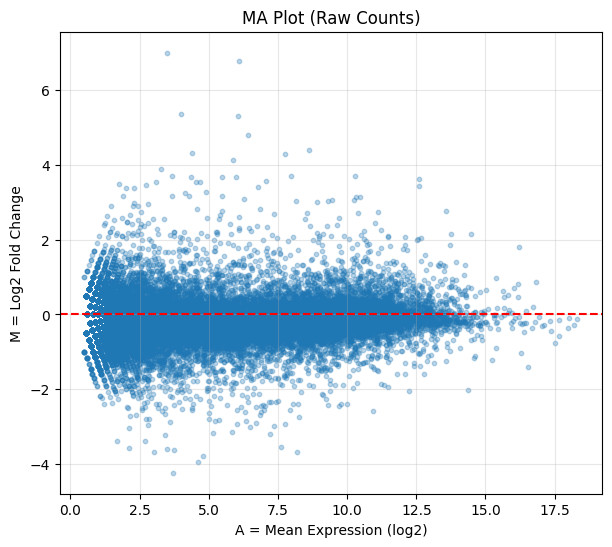

In [9]:
# Split samples
ctrl_samples = metadata[metadata["dex"] == "untrt"].index
trt_samples = metadata[metadata["dex"] == "trt"].index

# Mean per gene
mean_ctrl = raw_counts[ctrl_samples].mean(axis=1)
mean_trt = raw_counts[trt_samples].mean(axis=1)

# Compute M and A
M = np.log2(mean_trt + 1) - np.log2(mean_ctrl + 1)
A = 0.5 * (np.log2(mean_trt + 1) + np.log2(mean_ctrl + 1))

plt.figure(figsize=(7, 6))

plt.scatter(A, M, alpha=0.3, s=10)

plt.axhline(0, color='red', linestyle='--')
plt.xlabel("A = Mean Expression (log2)")
plt.ylabel("M = Log2 Fold Change")
plt.title("MA Plot (Raw Counts)")

plt.grid(alpha=0.3)
plt.show()

# Raw counts

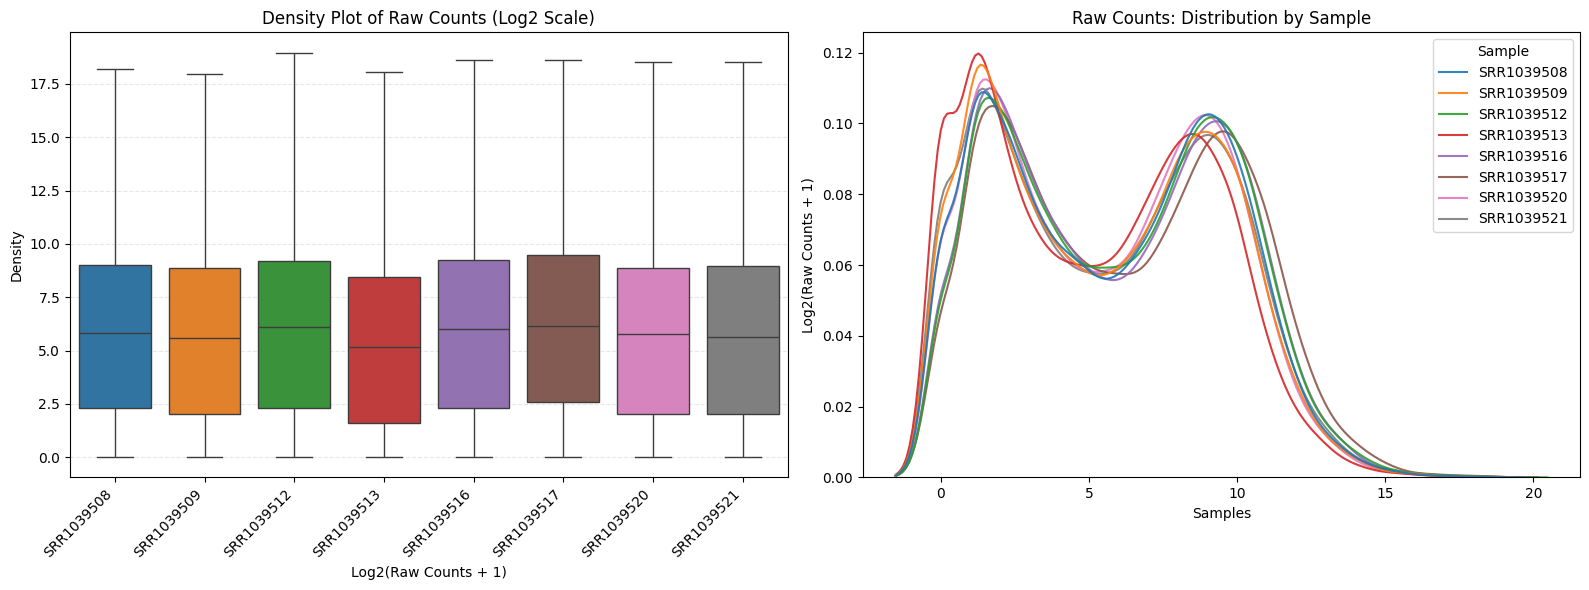

In [2]:
# Transpose so samples are rows
log_raw = np.log2(raw_counts + 1).T  # samples × genes

# Add metadata properly
log_raw["Sample"] = log_raw.index
log_raw = log_raw.merge(metadata, left_on="Sample", right_index=True)

# Melt to long format
plot_data_long_raw = log_raw.melt(
    id_vars=["Sample", "dex"],  
    var_name="Gene",
    value_name="Log2_Counts"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# --- Boxplot ---
sns.boxplot(
    data=plot_data_long_raw,
    x='Sample',
    y='Log2_Counts',
    hue='Sample',
    dodge=False,
    ax=axes[0]   # <-- key
)

axes[1].set_title("Raw Counts: Distribution by Sample")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Log2(Raw Counts + 1)")
#axes[1].tick_params(axis='x', rotation=0)



# --- Density plot ---
sns.kdeplot(
    data=plot_data_long_raw,
    x="Log2_Counts",
    hue="Sample",
    alpha=0.9,
    common_norm=False,
    bw_adjust=1,
    ax=axes[1]   # <-- key
)

axes[0].set_title("Density Plot of Raw Counts (Log2 Scale)")
axes[0].set_xlabel("Log2(Raw Counts + 1)")
axes[0].set_ylabel("Density")
axes[0].grid(axis='y', linestyle='--', alpha=0.3)


plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# CPM 

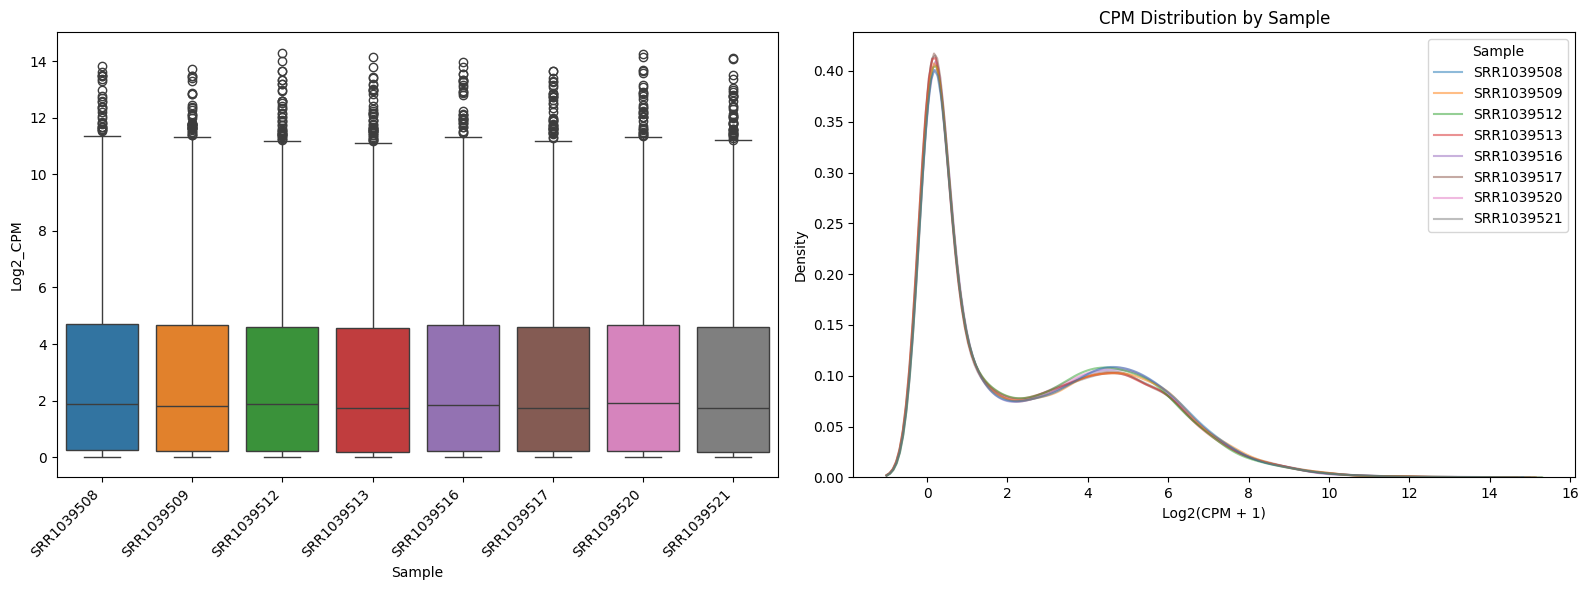

In [6]:
cpm = (raw_counts / raw_counts.sum(axis=0)) * 1e6
log_cpm = np.log2(cpm + 1)

plot_data = log_cpm.T.copy()
plot_data["Sample"] = plot_data.index
plot_data["dex"] = plot_data["Sample"].map(metadata["dex"])

plot_data_long = plot_data.melt(
    id_vars=["Sample", "dex"],
    var_name="Gene",
    value_name="Log2_CPM"
)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Density
sns.kdeplot(
    data=plot_data_long,
    x="Log2_CPM",
    hue="Sample",
    alpha=0.5,
    common_norm=False,
    ax=axes[1]
)

axes[1].set_title("Density Plot (CPM)")
axes[1].set_xlabel("Log2(CPM + 1)")
axes[1].set_ylabel("Density")

# Boxplot
sns.boxplot(
    data=plot_data_long,
    x="Sample",
    y="Log2_CPM",
    hue="Sample",
    dodge=False,
    ax=axes[0]
)

axes[1].set_title("CPM Distribution by Sample")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# TPM 

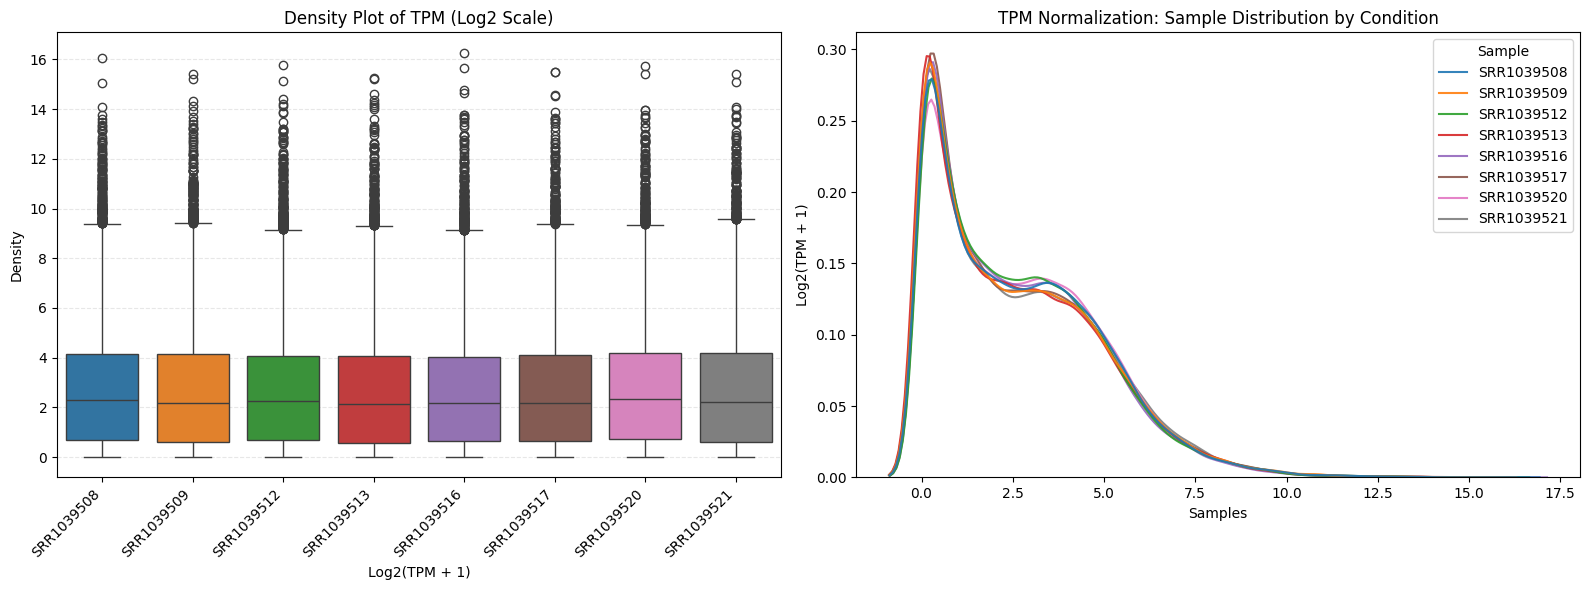

In [38]:
# Align IDs
raw_counts.index = raw_counts.index.str.split(".").str[0]
gene_info.index = gene_info.index.str.split(".").str[0]

# Map lengths safely
gene_lengths = gene_info["length"].reindex(raw_counts.index)

# Drop genes without length info
mask = gene_lengths.notna()
raw_counts = raw_counts[mask]
gene_lengths = gene_lengths[mask]

# TPM
lengths_kb = gene_lengths / 1000
rpk = raw_counts.divide(lengths_kb, axis=0)
tpm = (rpk / rpk.sum(axis=0)) * 1e6
log_tpm = np.log2(tpm + 1)

# 1. Prepare data for plotting (Transforming to 'Long Format')
# We join metadata first, then reset index so 'Sample' becomes a column
plot_data = log_tpm.T.join(metadata).reset_index().rename(columns={'index': 'Sample'})

# Now we melt, but we keep BOTH 'Sample' and 'dex' as identifier variables
plot_data_long = plot_data.melt(id_vars=['Sample', 'dex'], var_name='Gene', value_name='Log2_TPM')

# 2. Create the Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))



# --- Boxplot ---
sns.boxplot(
    data=plot_data_long,
    x='Sample',
    y='Log2_TPM',
    hue='Sample',
    dodge=False,
    ax=axes[0]   # <-- key
)

axes[1].set_title("TPM Normalization: Sample Distribution by Condition")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Log2(TPM + 1)")
#axes[1].tick_params(axis='x', rotation=0)



# --- Density plot ---
sns.kdeplot(
    data=plot_data_long,
    x="Log2_TPM",
    hue="Sample",
    alpha=0.9,
    common_norm=False,
    bw_adjust=1,
    ax=axes[1]   # <-- key
)

axes[0].set_title("Density Plot of TPM (Log2 Scale)")
axes[0].set_xlabel("Log2(TPM + 1)")
axes[0].set_ylabel("Density")
axes[0].grid(axis='y', linestyle='--', alpha=0.3)


plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# DESeq2 normalization (PyDESeq2)

Fitting size factors...
... done in 0.00 seconds.

/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:281: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_.T + self.intercept_
Fitting dispersions...
... done in 1.13 seconds.

Fitting dispersion trend curve...
/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/pydeseq2/default_inference.py:211: RuntimeWarning: divide by zero encountered in matmul
  mu = covariates_fit @ coeffs
/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/pydeseq2/default_inference.py:21

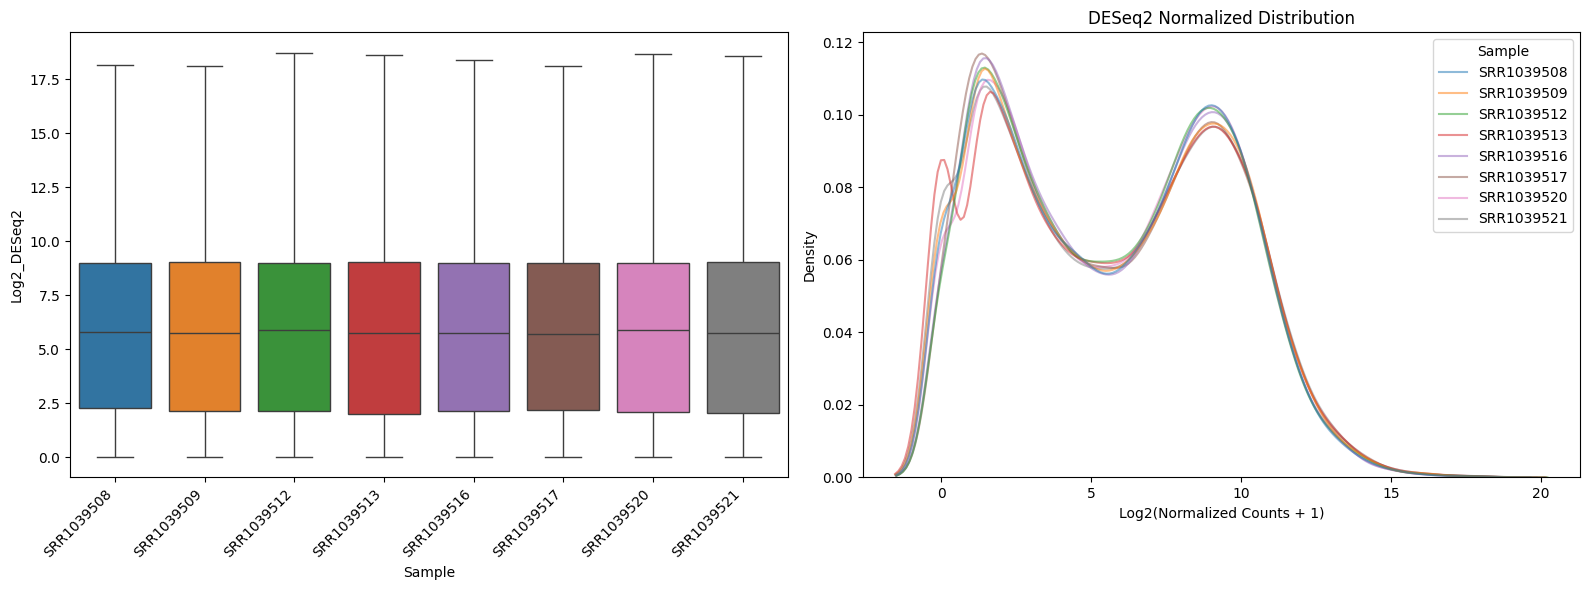

In [8]:
from pydeseq2.dds import DeseqDataSet

dds = DeseqDataSet(
    counts=raw_counts.T,
    metadata=metadata,
    design_factors="dex"
)

dds.deseq2()

norm_counts = pd.DataFrame(
    dds.layers["normed_counts"],
    index=raw_counts.columns,
    columns=raw_counts.index
).T

log_deseq = np.log2(norm_counts + 1)


plot_data = log_deseq.T.copy()
plot_data["Sample"] = plot_data.index
plot_data["dex"] = plot_data["Sample"].map(metadata["dex"])

plot_data_long = plot_data.melt(
    id_vars=["Sample", "dex"],
    var_name="Gene",
    value_name="Log2_DESeq2"
)



fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Density
sns.kdeplot(
    data=plot_data_long,
    x="Log2_DESeq2",
    hue="Sample",
    alpha=0.5,
    common_norm=False,
    ax=axes[1]
)

axes[1].set_title("Density Plot (DESeq2 Normalized)")
axes[1].set_xlabel("Log2(Normalized Counts + 1)")
axes[1].set_ylabel("Density")

# Boxplot
sns.boxplot(
    data=plot_data_long,
    x="Sample",
    y="Log2_DESeq2",
    hue="Sample",
    dodge=False,
    ax=axes[0]
)

axes[1].set_title("DESeq2 Normalized Distribution")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# MA plot for DESeq2

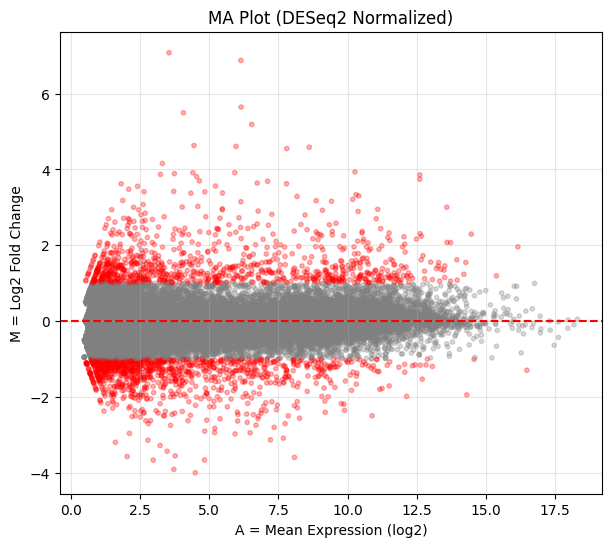

In [14]:
# Use normalized counts
mean_ctrl = norm_counts[ctrl_samples].mean(axis=1)
mean_trt = norm_counts[trt_samples].mean(axis=1)

M = np.log2(mean_trt + 1) - np.log2(mean_ctrl + 1)
A = 0.5 * (np.log2(mean_trt + 1) + np.log2(mean_ctrl + 1))

fc_threshold = 1  # log2 fold change
colors = np.where(abs(M) > fc_threshold, "red", "gray")

plt.figure(figsize=(7, 6))

plt.scatter(A, M, c=colors, alpha=0.3, s=10)

plt.axhline(0, color='red', linestyle='--')
plt.xlabel("A = Mean Expression (log2)")
plt.ylabel("M = Log2 Fold Change")
plt.title("MA Plot (DESeq2 Normalized)")

plt.grid(alpha=0.3)
plt.show()


# QC
## 1. PCA (Pre vs Post Normalization)

/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: inval

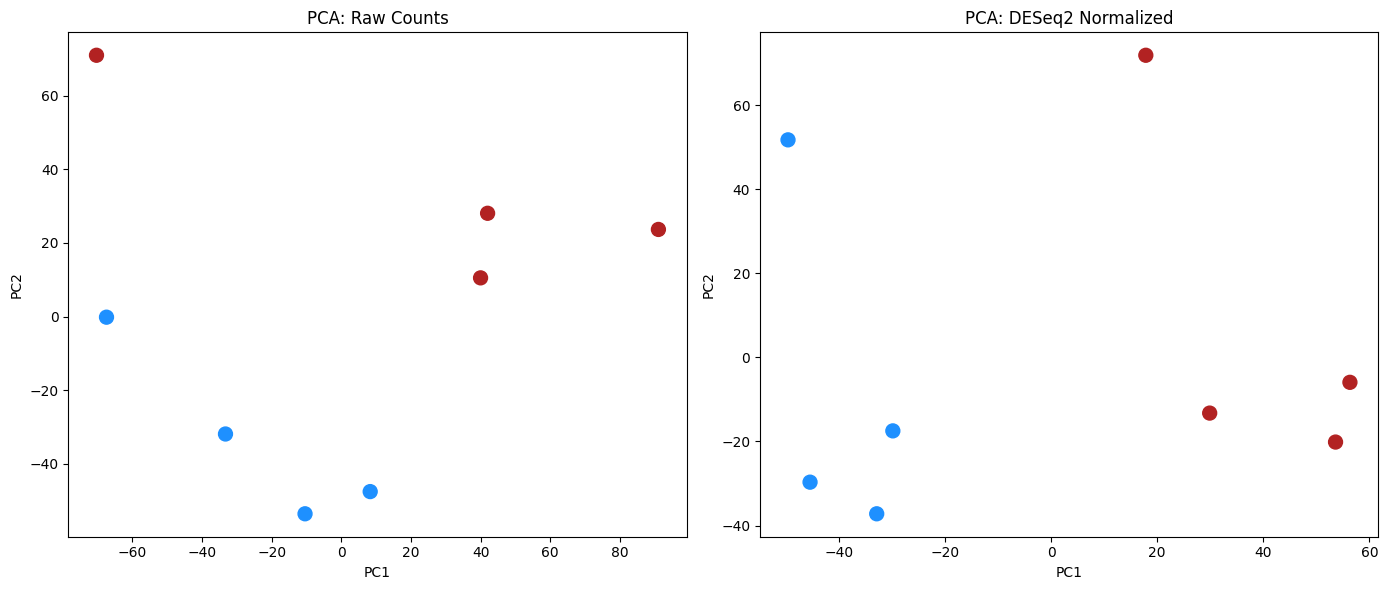

In [19]:
from sklearn.decomposition import PCA

# Log transform
# filter low-expression genes
mask = (raw_counts > 5).sum(axis=1) >= 2
log_raw = np.log2(raw_counts[mask] + 1)
log_norm = np.log2(norm_counts[mask] + 1)


# PCA
pca = PCA(n_components=2)

pca_raw = pca.fit_transform(log_raw.T)
pca_norm = pca.fit_transform(log_norm.T)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = metadata["dex"].map({"untrt": "dodgerblue", "trt": "firebrick"})

# Raw
axes[0].scatter(pca_raw[:, 0], pca_raw[:, 1], c=colors, s=100)
axes[0].set_title("PCA: Raw Counts")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Normalized
axes[1].scatter(pca_norm[:, 0], pca_norm[:, 1], c=colors, s=100)
axes[1].set_title("PCA: DESeq2 Normalized")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

## 2. Sample-to-Sample Distances

/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


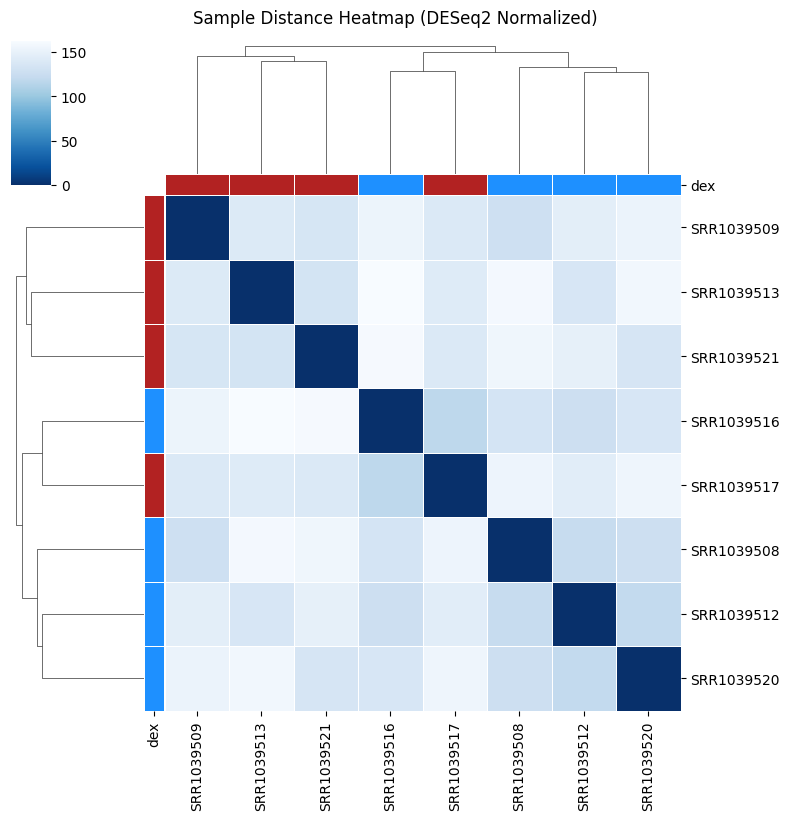

In [32]:
# --- Sample-to-Sample Distance Heatmap with Clustering ---

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

# 1. Use normalized log data (recommended)
log_norm = np.log2(norm_counts + 1)

# 2. Compute distance matrix
dist = pdist(log_norm.T, metric="euclidean")
dist_matrix = pd.DataFrame(
    squareform(dist),
    index=log_norm.columns,
    columns=log_norm.columns
)

# 3. Create condition color annotation
lut = {"untrt": "dodgerblue", "trt": "firebrick"}
col_colors = metadata.loc[dist_matrix.columns, "dex"].map(lut)

# 4. Plot clustermap
sns.clustermap(
    dist_matrix,
    cmap="Blues_r",
    row_colors=col_colors,
    col_colors=col_colors,
    robust=True,              # removes influence of extreme values
    linewidths=0.5,
    figsize=(8, 8)
)

plt.suptitle("Sample Distance Heatmap (DESeq2 Normalized)", y=1.02)
plt.show()

##  3. Total Library Size

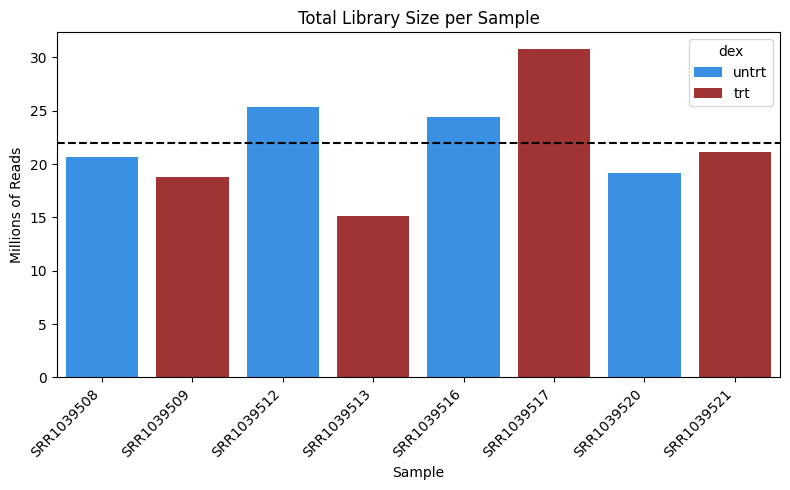

In [31]:
lib_sizes = raw_counts.sum(axis=0) / 1e6  # millions

plot_df = pd.DataFrame({
    "Sample": lib_sizes.index,
    "LibrarySize": lib_sizes.values,
    "dex": metadata.loc[lib_sizes.index, "dex"]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=plot_df,
    x="Sample",
    y="LibrarySize",
    hue="dex",
    palette={"untrt": "dodgerblue", "trt": "firebrick"}
)

plt.axhline(np.mean(lib_sizes), color='black', linestyle='--')

# ✅ FIX
plt.setp(plt.gca().get_xticklabels(), rotation=45, ha='right')

plt.title("Total Library Size per Sample")
plt.ylabel("Millions of Reads")

plt.tight_layout()
plt.show()

## Hierarchical Clustering of Samples and Genes

/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/peymanchoopanian/Library/Python/3.9/lib/python/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


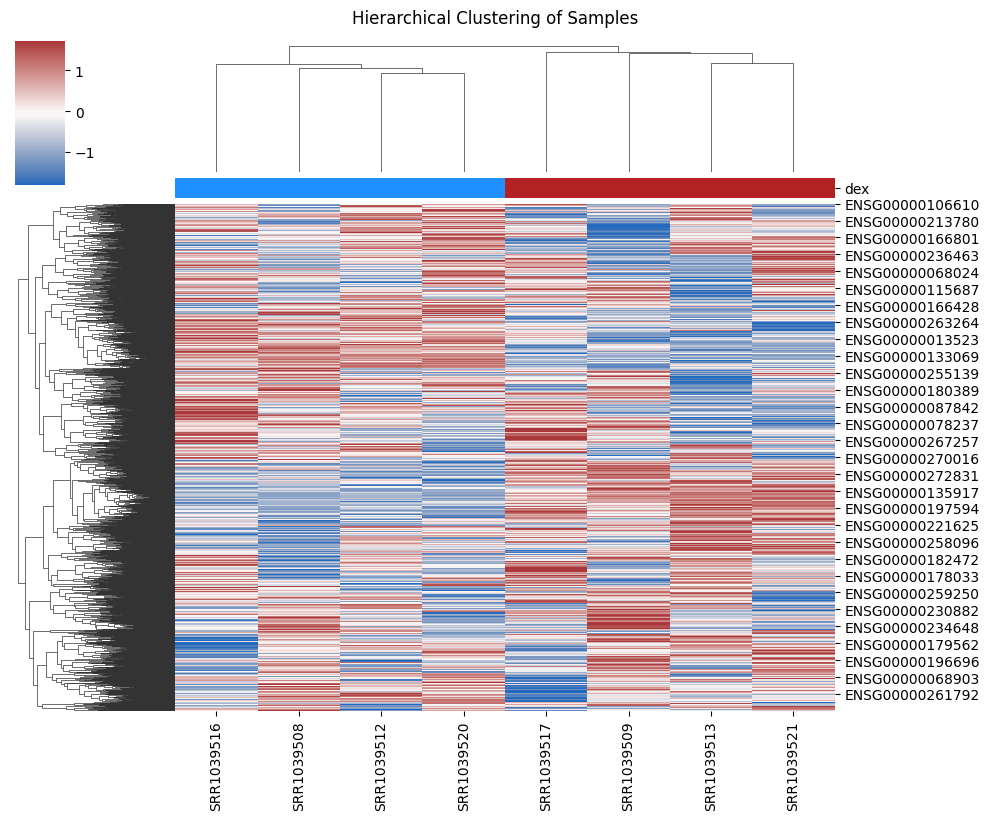

In [37]:
sns.clustermap(
    log_norm,
    cmap="vlag",
    col_colors=col_colors,
    z_score=0,     # normalize genes
    robust=True,
    figsize=(10, 8)
)

plt.suptitle("Hierarchical Clustering of Samples and Genes", y=1.02)
plt.show()